# <center>Recovering a signal by the method of least squares</center>

## Definition.
A _real trigonometric polynomial_ is an expression of the form
\begin{equation*}
f(t) = a_0 + \sum_{n=1}^N\left(a_n\sin(n\pi t) + b_n\cos(n\pi t)\right),
\end{equation*}
where the coefficients $a_n$ and $b_n$ are all real numbers.

Trig polynomials are often used to model signals.

## Example.
The function $s(t) = \frac{1}{2} + \sin(\pi t) - 2\cos(\pi t)$ is a trig polynomial.

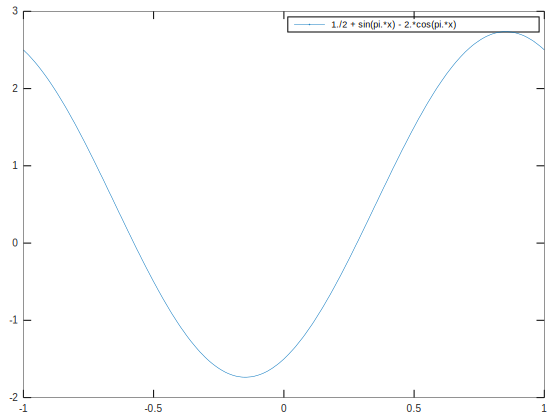

In [1]:
fplot("1/2 + sin(pi*x) - 2*cos(pi*x)", [-1 1])

* We don't typically observe signals as continuous functions.
* We usually observe/measure discrete samples.

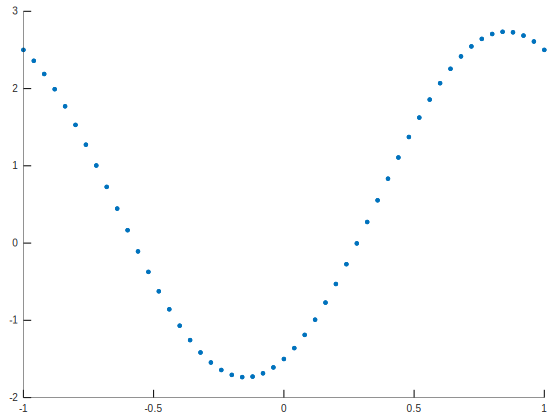

In [2]:
s = @(x) 1/2 + sin(pi*x) - 2*cos(pi*x);
n=51;
t=-1:2/(n-1):1;
y = s(t);
scatter(t,y,"filled")

* To be honest, there is usually noise in the channel.

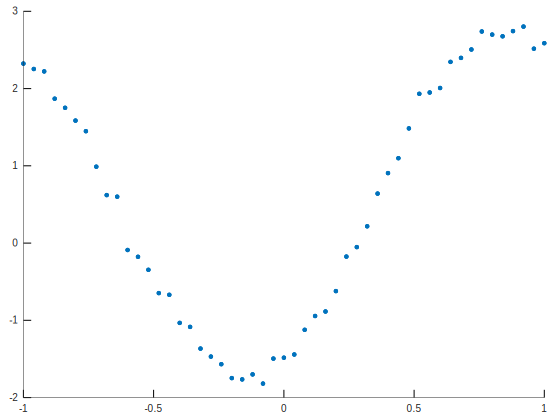

In [3]:
pkg load statistics
mu=0;
sigma=1/10;
y = s(t) + normrnd(mu,sigma,1,n); # added gaussian noise with mean 0 and standard deviation 1/10
scatter(t,y,"filled")

## Recovering a signal from discrete observations.

* Suppose that we expect the signal to have the form
\begin{equation*}
f(t) = a_0 + a_1\sin(\pi t) + b_1\cos(\pi t).
\end{equation*}
* Each observation, puts a linear constraint on the coefficients $a_0$, $a_1$, and $b_1$:
\begin{equation*}
a_0 + a_1\sin(\pi t_i) + b_1\cos(\pi t_i) = y_i,
\end{equation*}
where $y_i$ is the observation at time $t_i$.

* In theory, we only need 3 equations to determine these 3 unknowns.
* If $y_0$, $y_1$, and $y_2$ are the observations at times $t_0$, $t_1,$ and $t_2$, then we have the system

\begin{equation}
\begin{bmatrix}
1 & \sin(\pi t_0) & \cos(\pi t_0)\\
1 & \sin(\pi t_1) & \cos(\pi t_1)\\
1 & \sin(\pi t_2) & \cos(\pi t_2)\\
\end{bmatrix}
\begin{bmatrix}
a_0\\ a_1\\ b_1
\end{bmatrix}=
\begin{bmatrix}
y_0\\ y_1\\ y_2
\end{bmatrix}
\end{equation}

In [4]:
# Let's choose samples at times t=-1,0,1.
T = t([1 (n+1)/2 n])'; # if n is odd, then sample (n+1)/2 corresponds to t=0.
Y = y([1 (n+1)/2 n])';
A = [ones(3,1) sin(pi*T) cos(pi*T)];
[A Y]
rref([A Y]) # There is no solution!

ans =

   1.00000  -0.00000  -1.00000   2.32265
   1.00000   0.00000   1.00000  -1.48395
   1.00000   0.00000  -1.00000   2.58673

ans =

   1.00000  -0.00000   0.00000   0.00000
   0.00000   0.00000   1.00000   0.00000
   0.00000   0.00000   0.00000   1.00000



In [5]:
# Let's choose the first 3 samples.
T = t(1:3)';
Y = y(1:3)';
A = [ones(3,1) sin(pi*T) cos(pi*T)];
[A Y]
rref([A Y]) # There is a solution this time, but...
linsolve(A,Y) # linsolve doesn't help much here either (3 observations isn't enough).

ans =

   1.0000e+00  -1.2246e-16  -1.0000e+00   2.3227e+00
   1.0000e+00  -1.2533e-01  -9.9211e-01   2.2536e+00
   1.0000e+00  -2.4869e-01  -9.6858e-01   2.2225e+00

ans =

   1.00000   0.00000   0.00000   4.66224
   0.00000   1.00000   0.00000   0.69824
   0.00000   0.00000   1.00000   2.33959

ans =

   4.66224
   0.69824
   2.33959



* Don't bother trying to guess which 3 equations to use!
* There's no way to know which 3 have the least amount of noise.
* The solution is to use all of the observations and find a least squares solution.
* In the code below we force MATLAB/Octave to solve the normal equations.

c =

   0.51406
   1.01119
  -1.98825



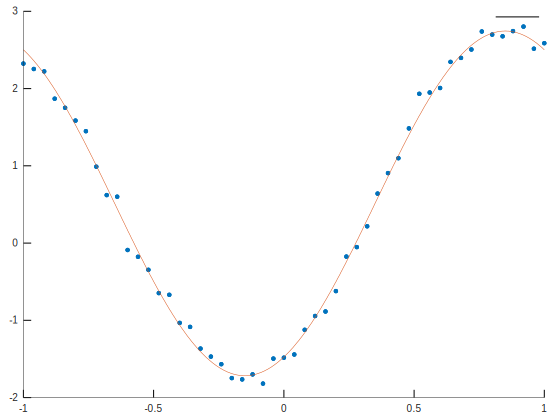

In [6]:
A = [ones(n,1) sin(pi*t') cos(pi*t')];
Y=y';
c=linsolve(A'*A,A'*Y) # Construct and solve the normal equations.
f = @(x) c(1) + c(2)*sin(pi*x) + c(3)*cos(pi*x);
hold on;
scatter(t,y,"filled")
fplot(f,[-1 1])
hold off;

* MATLAB/Octave automatically detects when an overdetermined system has no exact solution. 
* It will compute a least squares solution when necessary.
* MATLAB/Octave is actually doing something more robust (QR decomposition) than solving the normal equations.
* The two methods do not always perform the same. 
* If you want to compare them, you will have to manually construct the normal equations as we did above.

In [7]:
linsolve(A,Y) # Uses Gram--Schmidt (QR decomposition) under the hood.

ans =

   0.51406
   1.01119
  -1.98825

